In [1]:
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
from matplotlib import ticker

data_root = Path("D:\\데이터\\건축데이터 건축허브 개방데이터")
path_DB = data_root / "건축물대장_2025년_02월.db"

In [2]:
# Open a DuckDB connection
con = duckdb.connect(database=path_DB, read_only=True)

# print the list of tables in the database
tables = con.execute("SHOW TABLES").fetchall()
print("Tables in the database:")
for table in tables:
    print(table[0])
    print()

# show heads of the tables
for table in tables:
    table_name = table[0]
    print(f"Head of {table_name}:")
    df = con.execute(f"SELECT * FROM {table_name} LIMIT 5").fetchdf()
    print(df)
    print()

Tables in the database:
기본개요

총괄표제부

층별개요

표제부

Head of 기본개요:
  관리_건축물대장_PK 관리_상위_건축물대장_PK 대장_구분_코드 대장_구분_코드_명 대장_종류_코드 대장_종류_코드_명  \
0      100211           None        1         일반        1      총괄표제부   
1      100215           None        1         일반        1      총괄표제부   
2      100216           None        1         일반        1      총괄표제부   
3      100218           None        1         일반        1      총괄표제부   
4      100219           None        1         일반        1      총괄표제부   

                  대지_위치                  도로명_대지_위치  건물_명 시군구_코드  ...  \
0  서울특별시 종로구 관철동 12-1번지   서울특별시 종로구 종로14길 20 (관철동)  None  11110  ...   
1  서울특별시 종로구 청진동 21-1번지  서울특별시 종로구 종로5길 32-6 (청진동)  None  11110  ...   
2  서울특별시 종로구 중학동 16-2번지                       None  None  11110  ...   
3  서울특별시 종로구 중학동 24-1번지      서울특별시 종로구 율곡로 5 (중학동)  None  11110  ...   
4  서울특별시 종로구 중학동 35-1번지                       None  None  11110  ...   

  새주소_지상지하_코드 새주소_본_번 새주소_부_번 지역_코드 지구_코드 구역_코드 지역_코드_명  지구_코드_명 구역_코드_명

In [3]:
# Get the list of tables in the database
tables = con.execute("SHOW TABLES").fetchall()

print("=== COLUMN COUNT SUMMARY ===")
column_counts = []

for table in tables:
    table_name = table[0]
    columns_info = con.execute(f"DESCRIBE {table_name}").fetchdf()
    column_count = len(columns_info)
    column_names = list(columns_info["column_name"])

    column_counts.append(
        {
            "Table Name": table_name,
            "Column Count": column_count,
            "Column Names": ", ".join(column_names),
        }
    )

column_counts_df = pd.DataFrame(column_counts)
# Use context manager to temporarily set pandas display options
with pd.option_context(
    "display.max_columns",
    None,
    "display.max_colwidth",
    None,
    "display.width",
    None,
    "display.max_rows",
    None,
):
    display(column_counts_df)


=== COLUMN COUNT SUMMARY ===


,Table Name,Column Count,Column Names
0,기본개요,30,"관리_건축물대장_PK, 관리_상위_건축물대장_PK, 대장_구분_코드, 대장_구분_코드_명, 대장_종류_코드, 대장_종류_코드_명, 대지_위치, 도로명_대지_위치, 건물_명, 시군구_코드, 법정동_코드, 대지_구분_코드, 번, 지, 특수지_명, 블록, 로트, 외필지_수, 새주소_도로_코드, 새주소_법정동_코드, 새주소_지상지하_코드, 새주소_본_번, 새주소_부_번, 지역_코드, 지구_코드, 구역_코드, 지역_코드_명, 지구_코드_명, 구역_코드_명, 생성_일자"
1,총괄표제부,64,"관리_건축물대장_PK, 대장_구분_코드, 대장_구분_코드_명, 대장_종류_코드, 대장_종류_코드_명, 신_구_대장_구분_코드, 신_구_대장_구분_코드_명, 대지_위치, 도로명_대지_위치, 건물_명, 시군구_코드, 법정동_코드, 대지_구분_코드, 번, 지, 특수지_명, 블록, 로트, 외필지_수, 새주소_도로_코드, 새주소_법정동_코드, 새주소_지상지하_코드, 새주소_본_번, 새주소_부_번, 대지_면적(㎡), 건축_면적(㎡), 건폐_율(%), 연면적(㎡), 용적_률_산정_연면적(㎡), 용적_률(%), 주_용도_코드, 주_용도_코드_명, 기타_용도, 세대_수(세대), 가구_수(가구), 주_건축물_수, 부속_건축물_수, 부속_건축물_면적(㎡), 총_주차_수, 옥내_기계식_대수(대), 옥내_기계식_면적(㎡), 옥외_기계식_대수(대), 옥외_기계식_면적(㎡), 옥내_자주식_대수(대), 옥내_자주식_면적(㎡), 옥외_자주식_대수(대), 옥외_자주식_면적(㎡), 허가_일, 착공_일, 사용승인_일, 허가번호_년, 허가번호_기관_코드, 허가번호_기관_코드_명, 허가번호_구분_코드, 허가번호_구분_코드_명, 호_수(호), 에너지효율_등급, 에너지절감_율, 에너지_EPI점수, 친환경_건축물_등급, 친환경_건축물_인증점수, 지능형_건축물_등급, 지능형_건축물_인증점수, 생성_일자"
2,층별개요,33,"관리_건축물대장_PK, 대지_위치, 도로명_대지_위치, 건물_명, 시군구_코드, 법정동_코드, 대지_구분_코드, 번, 지, 특수지_명, 블록, 로트, 새주소_도로_코드, 새주소_법정동_코드, 새주소_지상지하_코드, 새주소_본_번, 새주소_부_번, 동_명, 층_구분_코드, 층_구분_코드_명, 층_번호, 층_번호_명, 구조_코드, 구조_코드_명, 기타_구조, 주_용도_코드, 주_용도_코드_명, 기타_용도, 면적(㎡), 주_부속_구분_코드, 주_부속_구분_코드_명, 면적_제외_여부, 생성_일자"
3,표제부,77,"관리_건축물대장_PK, 대장_구분_코드, 대장_구분_코드_명, 대장_종류_코드, 대장_종류_코드_명, 대지_위치, 도로명_대지_위치, 건물_명, 시군구_코드, 법정동_코드, 대지_구분_코드, 번, 지, 특수지_명, 블록, 로트, 외필지_수, 새주소_도로_코드, 새주소_법정동_코드, 새주소_지상지하_코드, 새주소_본_번, 새주소_부_번, 동_명, 주_부속_구분_코드, 주_부속_구분_코드_명, 대지_면적(㎡), 건축_면적(㎡), 건폐_율(%), 연면적(㎡), 용적_률_산정_연면적(㎡), 용적_률(%), 구조_코드, 구조_코드_명, 기타_구조, 주_용도_코드, 주_용도_코드_명, 기타_용도, 지붕_코드, 지붕_코드_명, 기타_지붕, 세대_수(세대), 가구_수(가구), 높이(m), 지상_층_수, 지하_층_수, 승용_승강기_수, 비상용_승강기_수, 부속_건축물_수, 부속_건축물_면적(㎡), 총_동_연면적(㎡), 옥내_기계식_대수(대), 옥내_기계식_면적(㎡), 옥외_기계식_대수(대), 옥외_기계식_면적(㎡), 옥내_자주식_대수(대), 옥내_자주식_면적(㎡), 옥외_자주식_대수(대), 옥외_자주식_면적(㎡), 허가_일, 착공_일, 사용승인_일, 허가번호_년, 허가번호_기관_코드, 허가번호_기관_코드_명, 허가번호_구분_코드, 허가번호_구분_코드_명, 호_수(호), 에너지효율_등급, 에너지절감_율, 에너지_EPI점수, 친환경_건축물_등급, 친환경_건축물_인증점수, 지능형_건축물_등급, 지능형_건축물_인증점수, 생성_일자, 내진_설계_적용_여부, 내진_능력"


In [4]:
table_name = "층별개요"
query = f"""SELECT
    *
FROM
    (SUMMARIZE "{table_name}");
"""
con.sql(query).show(max_rows=1_000)

┌──────────────────────┬───────────────┬───────────────────────────────────────────┬────────────────────────────────────────────┬───────────────┬────────────────────┬────────────────────┬─────────┬─────────┬─────────┬──────────┬─────────────────┐
│     column_name      │  column_type  │                    min                    │                    max                     │ approx_unique │        avg         │        std         │   q25   │   q50   │   q75   │  count   │ null_percentage │
│       varchar        │    varchar    │                  varchar                  │                  varchar                   │     int64     │      varchar       │      varchar       │ varchar │ varchar │ varchar │  int64   │  decimal(9,2)   │
├──────────────────────┼───────────────┼───────────────────────────────────────────┼────────────────────────────────────────────┼───────────────┼────────────────────┼────────────────────┼─────────┼─────────┼─────────┼──────────┼─────────────────┤
│ 관리_건축물대장_P

필요 컬럼:
- 면적 (0은 결측. 0보다 커야)
- 주/부속 구분 코드(주용도 층만 집계)
- 사용승인일 (연도)
- 시군구코드

존재 컬럼:
- 면적 (검증 필요)
- 주/부속 구분 코드(0만 선택)
- 시군구코드(연계 검증 필요)

없는 컬럼:
- 사용승인일

In [5]:
query = """
SELECT 
    f.관리_건축물대장_PK,
    f.대지_위치,
    f.도로명_대지_위치,
    f.건물_명,
    f.시군구_코드,
    f.법정동_코드,
    f.동_명,
    f.층_구분_코드,
    f.층_구분_코드_명,
    f.층_번호,
    f.층_번호_명,
    f.주_용도_코드,
    f.주_용도_코드_명,
    f.기타_용도,
    f."면적(㎡)",
    f.주_부속_구분_코드,
    f.주_부속_구분_코드_명,
    f.면적_제외_여부,
    f.생성_일자,
    b."사용승인_일",
FROM 층별개요 f
INNER JOIN 표제부 b
ON f.관리_건축물대장_PK = b.관리_건축물대장_PK
"""
층별개요_표제부 = con.sql(query)
층별개요_표제부.limit(5).show()

┌────────────────────┬─────────────────────────────────────┬─────────────────────────────────────────────┬───────────┬─────────────┬─────────────┬─────────┬──────────────┬─────────────────┬─────────┬────────────┬──────────────┬─────────────────┬────────────────────┬───────────────┬───────────────────┬──────────────────────┬────────────────┬───────────┬─────────────┐
│ 관리_건축물대장_PK │              대지_위치              │              도로명_대지_위치               │  건물_명  │ 시군구_코드 │ 법정동_코드 │  동_명  │ 층_구분_코드 │ 층_구분_코드_명 │ 층_번호 │ 층_번호_명 │ 주_용도_코드 │ 주_용도_코드_명 │     기타_용도      │   면적(㎡)    │ 주_부속_구분_코드 │ 주_부속_구분_코드_명 │ 면적_제외_여부 │ 생성_일자 │ 사용승인_일 │
│      varchar       │               varchar               │                   varchar                   │  varchar  │   varchar   │   varchar   │ varchar │   varchar    │     varchar     │  int32  │  varchar   │   varchar    │     varchar     │      varchar       │ decimal(18,3) │      varchar      │       varchar        │    varchar     │  varchar  │   varc

In [66]:
query = """
SELECT *
FROM 층별개요_표제부
WHERE
    "면적(㎡)" > 0
    AND 주_부속_구분_코드 = '0'
    AND (면적_제외_여부 IS DISTINCT FROM '1')  -- exclude '1', but include NULLs
    AND 시군구_코드 BETWEEN '11001' AND '59999'
    AND 사용승인_일 BETWEEN '10000001' AND '20241231'  -- for year 2024
"""
valid = con.sql(query)
valid.limit(5).show()

┌────────────────────┬─────────────────────────────────────┬───────────────────────────────────────────┬──────────────┬─────────────┬─────────────┬─────────┬──────────────┬─────────────────┬─────────┬────────────┬──────────────┬───────────────────────┬─────────────────────┬───────────────┬───────────────────┬──────────────────────┬────────────────┬───────────┬─────────────┐
│ 관리_건축물대장_PK │              대지_위치              │             도로명_대지_위치              │   건물_명    │ 시군구_코드 │ 법정동_코드 │  동_명  │ 층_구분_코드 │ 층_구분_코드_명 │ 층_번호 │ 층_번호_명 │ 주_용도_코드 │    주_용도_코드_명    │      기타_용도      │   면적(㎡)    │ 주_부속_구분_코드 │ 주_부속_구분_코드_명 │ 면적_제외_여부 │ 생성_일자 │ 사용승인_일 │
│      varchar       │               varchar               │                  varchar                  │   varchar    │   varchar   │   varchar   │ varchar │   varchar    │     varchar     │  int32  │  varchar   │   varchar    │        varchar        │       varchar       │ decimal(18,3) │      varchar      │       varchar        │    varchar 

In [67]:
con.sql("SELECT COUNT(*) FROM 층별개요_표제부").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     21031213 │
└──────────────┘



In [68]:
con.sql("SELECT COUNT(*) FROM valid").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     18219978 │
└──────────────┘



In [69]:
query = """
SELECT *,
    LOG10("면적(㎡)") AS log_area
FROM valid
"""
log_area_view = con.sql(query)
log_area_view.limit(5).show()

┌────────────────────┬─────────────────────────────────────────┬──────────────────────────────────────────────────────┬─────────┬─────────────┬─────────────┬─────────┬──────────────┬─────────────────┬─────────┬────────────┬──────────────┬─────────────────┬──────────────┬───────────────┬───────────────────┬──────────────────────┬────────────────┬───────────┬─────────────┬────────────────────┐
│ 관리_건축물대장_PK │                대지_위치                │                   도로명_대지_위치                   │ 건물_명 │ 시군구_코드 │ 법정동_코드 │  동_명  │ 층_구분_코드 │ 층_구분_코드_명 │ 층_번호 │ 층_번호_명 │ 주_용도_코드 │ 주_용도_코드_명 │  기타_용도   │   면적(㎡)    │ 주_부속_구분_코드 │ 주_부속_구분_코드_명 │ 면적_제외_여부 │ 생성_일자 │ 사용승인_일 │      log_area      │
│      varchar       │                 varchar                 │                       varchar                        │ varchar │   varchar   │   varchar   │ varchar │   varchar    │     varchar     │  int32  │  varchar   │   varchar    │     varchar     │   varchar    │ decimal(18,3) │      varchar      │  

In [70]:
plt.style.use("../auri.mplstyle")

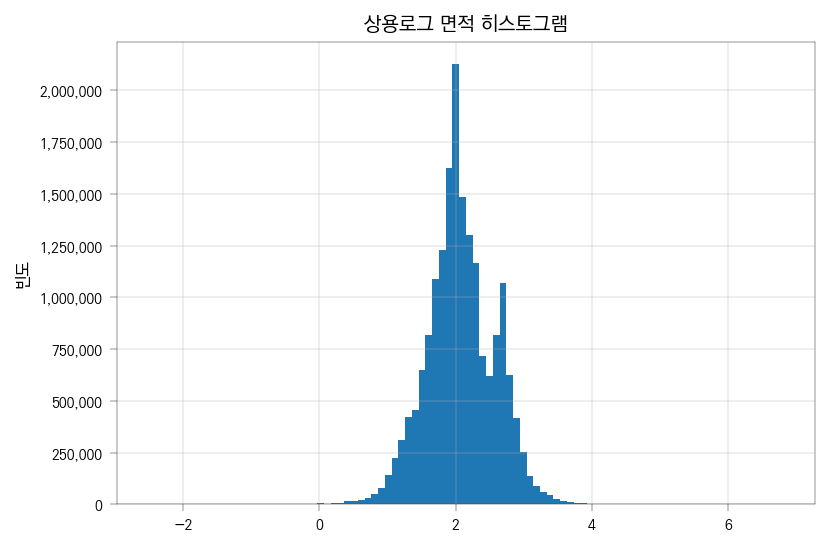

In [71]:
# DuckDB histogram: returns counts in 100 bins
res = con.sql(
    "SELECT * FROM histogram_values(log_area_view, log_area, bin_count := 100)"
).df()

plt.hist(res["bin"], weights=res["count"], bins=len(res))
plt.ylabel("빈도")
plt.title("상용로그 면적 히스토그램")
plt.grid(True)
# Set the format of tick labels to non-scientific
plt.ticklabel_format(style="plain", useOffset=False)
# Format the tick labels with commas for thousands
formatter = ticker.StrMethodFormatter("{x:,.0f}")  # This formats the number with commas
# plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

In [72]:
# remove top and bottom 0.05%
percentage = 0.0005  # should be < 0.5
query = f"""
WITH q AS (
  SELECT
    quantile_disc(log_area, {percentage})  AS q_low,
    quantile_disc(log_area, 1 - {percentage}) AS q_high
  FROM log_area_view
)
SELECT lav.*
FROM log_area_view AS lav, q
WHERE lav.log_area BETWEEN q.q_low AND q.q_high
"""
filtered = con.sql(query)
filtered.limit(5).show()


┌────────────────────┬─────────────────────────────────────────┬─────────────────────────────────────────────────────┬──────────────┬─────────────┬─────────────┬─────────┬──────────────┬─────────────────┬─────────┬────────────┬──────────────┬─────────────────┬───────────┬───────────────┬───────────────────┬──────────────────────┬────────────────┬───────────┬─────────────┬────────────────────┐
│ 관리_건축물대장_PK │                대지_위치                │                  도로명_대지_위치                   │   건물_명    │ 시군구_코드 │ 법정동_코드 │  동_명  │ 층_구분_코드 │ 층_구분_코드_명 │ 층_번호 │ 층_번호_명 │ 주_용도_코드 │ 주_용도_코드_명 │ 기타_용도 │   면적(㎡)    │ 주_부속_구분_코드 │ 주_부속_구분_코드_명 │ 면적_제외_여부 │ 생성_일자 │ 사용승인_일 │      log_area      │
│      varchar       │                 varchar                 │                       varchar                       │   varchar    │   varchar   │   varchar   │ varchar │   varchar    │     varchar     │  int32  │  varchar   │   varchar    │     varchar     │  varchar  │ decimal(18,3) │      varchar      

The comma in the FROM clause means cross join.
it means “take every row of log_area_view and join it with the single-row result of q.” That’s fine if q is an aggregate query returning one row with your quantiles — it just attaches those scalar values to every row of lav.

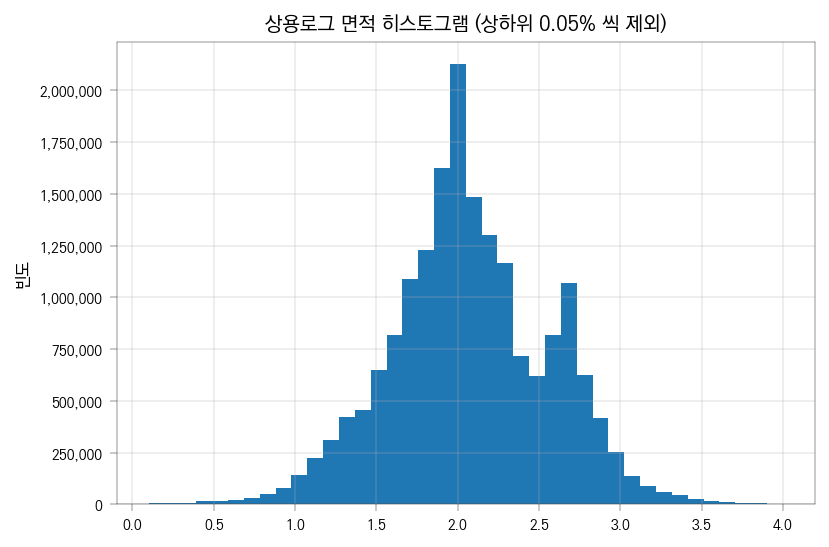

In [73]:
query = """
SELECT *
FROM histogram_values(filtered, log_area, bin_count := 50);
"""
res = con.sql(query).df()
plt.hist(res["bin"], weights=res["count"], bins=len(res))
plt.ylabel("빈도")
plt.title("상용로그 면적 히스토그램 (상하위 0.05% 씩 제외)")
plt.grid(True)
# Set the format of tick labels to non-scientific
plt.ticklabel_format(style="plain", useOffset=False)
# Format the tick labels with commas for thousands
formatter = ticker.StrMethodFormatter("{x:,.0f}")  # This formats the number with commas
# plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

In [76]:
h_list = [
    "01000",
    "01001",
    "01002",
    "01003",
    "01004",
    "01005",
    "01006",
    "01007",
    "01008",
    "02000",
    "02001",
    "02002",
    "02003",
    "02004",
    "02005",
    "02006",
    "02007",
    "02008",
    "02009",
    "02010",
    "02011",
    "1000",
    "1002",
    "1003",
    "1004",
    "2000",
    "2001",
    "2002",
    "2003",
    "2004",
    "2005",
    "2006",
    "2007",
]
h_df = pd.DataFrame(h_list, columns=["주_용도_코드"])
h_df

,주_용도_코드
0,01000
1,01001
2,01002
3,01003
4,01004
5,01005
6,01006
7,01007
8,01008
9,02000


In [77]:
query = """
SELECT
  CASE WHEN h.주_용도_코드 IS NOT NULL THEN '주거'
        ELSE '비주거'
  END AS 주거_여부,
  COUNT(*) AS 층수,
  SUM("면적(㎡)") AS 총면적
FROM filtered f
LEFT JOIN h_df h
ON f.주_용도_코드 = h.주_용도_코드
GROUP BY ALL;
"""
con.sql(query).show()

┌───────────┬──────────┬────────────────┐
│ 주거_여부 │   층수   │     총면적     │
│  varchar  │  int64   │ decimal(38,3)  │
├───────────┼──────────┼────────────────┤
│ 주거      │ 11080073 │ 1953738654.905 │
│ 비주거    │  7127167 │ 1858502170.825 │
└───────────┴──────────┴────────────────┘



In [79]:
query = """
SELECT
  시군구_코드,
  CASE WHEN h.주_용도_코드 IS NOT NULL THEN '주거'
        ELSE '비주거'
  END AS 주거_여부,
  substr(사용승인_일, 1, 4) AS 사용승인_연도,
  COUNT(*) AS 층수,
  SUM("면적(㎡)") AS 총면적
FROM filtered f
LEFT JOIN h_df h
ON f.주_용도_코드 = h.주_용도_코드
GROUP BY ALL
ORDER BY ALL;
"""
summed = con.sql(query)
summed.show()
summed.to_parquet("../data/processed/시군구_주거여부_연도별_층별면적_집계.parquet")

┌─────────────┬───────────┬───────────────┬───────┬───────────────┐
│ 시군구_코드 │ 주거_여부 │ 사용승인_연도 │ 층수  │    총면적     │
│   varchar   │  varchar  │    varchar    │ int64 │ decimal(38,3) │
├─────────────┼───────────┼───────────────┼───────┼───────────────┤
│ 11110       │ 비주거    │ 1899          │     3 │       773.560 │
│ 11110       │ 비주거    │ 1911          │     5 │       201.810 │
│ 11110       │ 비주거    │ 1912          │     8 │      2818.970 │
│ 11110       │ 비주거    │ 1914          │     1 │        17.550 │
│ 11110       │ 비주거    │ 1916          │     1 │        16.600 │
│ 11110       │ 비주거    │ 1917          │     7 │       259.980 │
│ 11110       │ 비주거    │ 1918          │     2 │       122.310 │
│ 11110       │ 비주거    │ 1922          │     3 │      1263.470 │
│ 11110       │ 비주거    │ 1923          │     4 │       188.200 │
│ 11110       │ 비주거    │ 1925          │     1 │        41.720 │
│   ·         │  ·        │  ·            │     · │           ·   │
│   ·         │  ·        │  ·